---
# **1. Setup**
---


In [1]:
import os
import json
import time
import math
import re
from pathlib import Path
from collections import Counter
import random

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import easyocr


In [2]:
# @title **Hyperparameters**
DATA_DIR      = Path("../data/raw/val")       # folder with .jpg images
JSON_PATH     = Path("../data/processed/vizwiz_cleaned.json") # cleaned captions JSON (list of records)
CHECKPOINT_DIR = Path("../data/checkpoints")
SEED = 42

VOCAB_SIZE    = 3352      # keep the N most-common words
MAX_SEQ_LEN   = 22        # max caption length (tokens)
IMG_SIZE      = 224       # ResNet input size
BATCH_SIZE    = 32
EPOCHS        = 15
LR            = 3e-4
GRAD_CLIP     = 5.0

# Transformer decoder dimensions
EMBED_DIM     = 256       # word + positional embedding size
NUM_HEADS     = 8         # attention heads  (EMBED_DIM must be divisible)
FF_DIM        = 512       # feed-forward hidden size inside transformer
NUM_LAYERS    = 3         # number of transformer decoder layers
DROPOUT       = 0.1

# Visual feature projection (ResNet101 outputs 2048-d)
VISUAL_DIM    = 2048
OCR_DIM       = 256       # projected OCR embedding size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:

# ─────────────────────────────────────────────
# 1.  VOCABULARY
#     Builds a word↔index mapping from captions.
# ─────────────────────────────────────────────

class Vocabulary:
    """
    Maps words to integer indices and back.

    Special tokens
    ──────────────
    <pad>  – padding (index 0)
    <sos>  – start of sequence (index 1)
    <eos>  – end of sequence (index 2)
    <unk>  – unknown word (index 3)
    """

    PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.pad_idx  = 0
        self.sos_idx  = 1
        self.eos_idx  = 2
        self.unk_idx  = 3
        # insert specials at fixed positions
        for idx, tok in enumerate([self.PAD, self.SOS, self.EOS, self.UNK]):
            self.word2idx[tok] = idx
            self.idx2word[idx] = tok

    def build(self, all_captions: list[list[str]], max_size: int):
        """Count words across all captions and keep the top `max_size`."""
        counter = Counter(w for cap in all_captions for w in cap)
        print(type(max_size))
        for word, _ in counter.most_common(max_size - 4):   # -4 for specials
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f"Vocabulary built: {len(self.word2idx)} tokens")

    def encode(self, tokens: list[str]) -> list[int]:
        return [self.word2idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, indices: list[int]) -> list[str]:
        return [self.idx2word.get(i, self.UNK) for i in indices]

    def __len__(self):
        return len(self.word2idx)


def simple_tokenise(text: str) -> list[str]:
    """Lowercase and split on non-alphanumeric characters."""
    return re.findall(r"\w+", text.lower())

In [4]:

# ─────────────────────────────────────────────
# 2.  DATASET
#     Loads an image + one caption per sample.
# ─────────────────────────────────────────────

# Standard ImageNet normalisation for ResNet
IMG_TRANSFORM = transforms.Compose([
    transforms.Resize(256), transforms.RandomCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


class VizWizDataset(Dataset):
    """
    One Dataset item = (image_tensor, caption_tensor, caption_length).

    For each image we randomly pick ONE of the human captions per epoch
    (only during training).  For val/test we always use caption index 0.
    """

    def __init__(self,
                 records: list[dict],
                 vocab: Vocabulary,
                 img_dir: Path,
                 split: str,               # 'train' | 'val' | 'test'
                 transform=IMG_TRANSFORM):
        self.records   = records
        self.vocab     = vocab
        self.img_dir   = img_dir
        self.split     = split
        self.transform = transform
        self.is_train  = (split == "train")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        # ── image ────────────────────────────────
        img_path = self.img_dir / rec["filename"]
        image    = Image.open(img_path).convert("RGB")
        img_tensor = self.transform(image)

        # ── caption ──────────────────────────────
        caps = rec["cleaned_captions"]
        cap_text = caps[torch.randint(len(caps), (1,)).item()] \
                   if self.is_train else caps[0]

        tokens  = simple_tokenise(cap_text)
        indices = (
            [self.vocab.sos_idx]
            + self.vocab.encode(tokens)[:MAX_SEQ_LEN - 2]   # leave room for eos
            + [self.vocab.eos_idx]
        )
        # pad to MAX_SEQ_LEN
        length  = len(indices)
        indices += [self.vocab.pad_idx] * (MAX_SEQ_LEN - length)
        cap_tensor = torch.tensor(indices, dtype=torch.long)

        return img_tensor, cap_tensor, length

class VizWizDatasetV2(VizWizDataset):
    """
    Extends VizWizDataset to also return the image filename.
    The filename is needed at training time to look up the pre-computed
    OCR vector from the cache dict.
    """
    def __getitem__(self, idx):
        img_t, cap_t, length = super().__getitem__(idx)
        return img_t, cap_t, length, self.records[idx]["filename"]
 
 
def collate_fn(batch):
    """Collate for VizWizDatasetV2: returns (imgs, caps, lens, fnames)."""
    imgs, caps, lens, fnames = zip(*batch)
    return torch.stack(imgs), torch.stack(caps), torch.tensor(lens), list(fnames)

In [5]:

# ─────────────────────────────────────────────
# 3.  OCR  FEATURE  EXTRACTOR
#     Runs EasyOCR on a batch of PIL images and
#     returns a fixed-size embedding per image.
# ─────────────────────────────────────────────

class OCREncoder(nn.Module):
    """
    For each image:
      1. EasyOCR reads any text found in the image.
      2. We embed each recognised word with a simple embedding layer.
      3. We mean-pool those word embeddings → one vector per image.
      4. A linear layer projects to OCR_DIM.

    The OCR reader runs on CPU (EasyOCR requirement).
    The embeddings are learnable, so the model can learn which OCR
    words are caption-relevant.
    """

    def __init__(self, vocab: Vocabulary, embed_dim: int, out_dim: int):
        super().__init__()
        # shared vocabulary → avoids a separate OCR vocab
        self.vocab      = vocab
        self.embedding  = nn.Embedding(len(vocab), embed_dim, padding_idx=vocab.pad_idx)
        self.projection = nn.Linear(embed_dim, out_dim)
        self.reader     = easyocr.Reader(["en"], gpu=torch.cuda.is_available(), verbose=False)

    def read_image(self, pil_image: Image.Image) -> list[str]:
        """Return list of words found by OCR in a PIL image."""
        results = self.reader.readtext(np.array(pil_image))
        words   = []
        for (_, text, conf) in results:
            if conf > 0.4:                       # confidence threshold
                words.extend(simple_tokenise(text))
        return words if words else ["<unk>"]     # ensure at least one token

    @torch.no_grad()
    def forward_ocr(self, pil_images: list[Image.Image]) -> torch.Tensor:
        """
        Run OCR on a list of PIL images → (batch, OCR_DIM) tensor.
        Called OUTSIDE the normal forward so gradients only flow through
        the embedding/projection, not through EasyOCR itself.
        """
        batch_vecs = []
        for img in pil_images:
            words   = self.read_image(img)
            indices = torch.tensor(self.vocab.encode(words), dtype=torch.long)
            embs    = self.embedding(indices)          # (n_words, embed_dim)
            pooled  = embs.mean(dim=0)                 # (embed_dim,)
            batch_vecs.append(pooled)
        batch_tensor = torch.stack(batch_vecs)         # (B, embed_dim)
        return self.projection(batch_tensor)           # (B, OCR_DIM)

    def forward(self, precomputed_ocr: torch.Tensor) -> torch.Tensor:
        """
        During training we pass the already-projected OCR vector straight
        through (it was computed in the training loop to keep DataLoader
        simple).
        """
        return precomputed_ocr



In [6]:

# ─────────────────────────────────────────────
# 4.  VISUAL  ENCODER  (ResNet101)
#     Extracts a spatial feature map from the image.
# ─────────────────────────────────────────────

class VisualEncoder(nn.Module):
    """
    ResNet101 pre-trained on ImageNet.

    We remove the final average-pool + FC layers so we keep the spatial
    feature map of shape (B, 2048, 7, 7) for a 224×224 input.
    That gives 49 "patch tokens" the decoder can attend to.

    A linear layer then projects 2048 → EMBED_DIM.
    """

    def __init__(self, embed_dim: int, fine_tune: bool = False):
        super().__init__()
        backbone = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)

        # everything except the last two layers (avgpool + fc)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-2])
        self.projection        = nn.Linear(VISUAL_DIM, embed_dim)

        # optionally fine-tune only the last ResNet block (layer4)
        for name, param in self.feature_extractor.named_parameters():
            param.requires_grad = fine_tune and ("layer4" in name)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        images : (B, 3, 224, 224)
        returns: (B, 49, EMBED_DIM)   — 49 spatial patch tokens
        """
        feats  = self.feature_extractor(images)    # (B, 2048, 7, 7)
        B, C, H, W = feats.shape
        feats  = feats.permute(0, 2, 3, 1)         # (B, 7, 7, 2048)
        feats  = feats.reshape(B, H * W, C)         # (B, 49, 2048)
        return self.projection(feats)               # (B, 49, EMBED_DIM)



In [7]:

# ─────────────────────────────────────────────
# 5.  POSITIONAL  ENCODING
#     Adds sine/cosine position signals to
#     the token embeddings (standard Transformer).
# ─────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """
    Classic sinusoidal positional encoding from "Attention Is All You Need".
    Adds a unique position-dependent signal to each token embedding so the
    model knows the order of words.
    """

    def __init__(self, embed_dim: int, max_len: int = 200, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # build the (max_len, embed_dim) encoding table once
        pe  = torch.zeros(max_len, embed_dim)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)   # (max_len, 1)
        div = torch.exp(
            torch.arange(0, embed_dim, 2, dtype=torch.float)
            * (-math.log(10000.0) / embed_dim)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))    # (1, max_len, embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, seq_len, embed_dim)"""
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)



In [8]:

# ─────────────────────────────────────────────
# 6.  CAPTION  DECODER  (Transformer)
#     BERT-style multi-head attention decoder.
# ─────────────────────────────────────────────

class CaptionDecoder(nn.Module):
    """
    Standard Transformer decoder.

    Each layer does:
      1. Masked self-attention  → attends to previous caption tokens only
                                   (causal / autoregressive mask)
      2. Cross-attention        → attends to visual+OCR memory
      3. Feed-forward network

    We use PyTorch's built-in TransformerDecoderLayer for clarity.
    """

    def __init__(self, vocab_size: int, embed_dim: int,
                 num_heads: int, ff_dim: int,
                 num_layers: int, dropout: float, max_len: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_enc   = PositionalEncoding(embed_dim, max_len, dropout)

        decoder_layer  = nn.TransformerDecoderLayer(
            d_model   = embed_dim,
            nhead     = num_heads,
            dim_feedforward = ff_dim,
            dropout   = dropout,
            batch_first = True,        # (B, seq, dim) convention
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, vocab_size)

    @staticmethod
    def _causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
        """
        Returns an upper-triangular mask so position i cannot attend to j > i.
        Shape: (seq_len, seq_len), True = BLOCKED.
        """
        return torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()

    def forward(self, memory: torch.Tensor,
                captions: torch.Tensor,
                pad_idx: int) -> torch.Tensor:
        """
        memory  : (B, mem_len, EMBED_DIM)  — visual + OCR context
        captions: (B, seq_len)             — shifted caption indices
        returns : (B, seq_len, vocab_size) — logits
        """
        seq_len  = captions.size(1)
        tgt_mask = self._causal_mask(seq_len, captions.device)
        tgt_key_padding_mask = (captions == pad_idx)   # True where padded

        tgt = self.embedding(captions)                 # (B, seq, EMBED_DIM)
        tgt = self.pos_enc(tgt)

        out = self.transformer(
            tgt                = tgt,
            memory             = memory,
            tgt_mask           = tgt_mask,
            tgt_key_padding_mask = tgt_key_padding_mask,
        )                                              # (B, seq, EMBED_DIM)
        return self.output_proj(out)                   # (B, seq, vocab_size)



In [9]:

# ─────────────────────────────────────────────
# 7.  FULL  MODEL
#     Combines visual encoder + OCR + decoder.
# ─────────────────────────────────────────────

class VizWizCaptioner(nn.Module):
    """
    Full image-captioning model.

    Forward signature
    ─────────────────
    images     : (B, 3, 224, 224)  — pre-normalised image tensors
    captions   : (B, seq_len)      — token indices (input side, i.e. without last token)
    ocr_feats  : (B, OCR_DIM)     — pre-computed OCR vectors (see training loop)

    Returns
    ───────
    logits     : (B, seq_len, vocab_size)
    """

    def __init__(self, vocab: Vocabulary,
                 embed_dim: int  = EMBED_DIM,
                 num_heads: int  = NUM_HEADS,
                 ff_dim: int     = FF_DIM,
                 num_layers: int = NUM_LAYERS,
                 dropout: float  = DROPOUT,
                 fine_tune_cnn: bool = False):
        super().__init__()

        self.vocab   = vocab
        self.encoder = VisualEncoder(embed_dim, fine_tune=fine_tune_cnn)

        # Project the OCR vector to match EMBED_DIM so we can concatenate
        # it with the visual patch tokens as extra "memory"
        self.ocr_proj = nn.Linear(OCR_DIM, embed_dim)

        self.decoder  = CaptionDecoder(
            vocab_size = len(vocab),
            embed_dim  = embed_dim,
            num_heads  = num_heads,
            ff_dim     = ff_dim,
            num_layers = num_layers,
            dropout    = dropout,
            max_len    = MAX_SEQ_LEN + 10,
        )

    def forward(self, images: torch.Tensor,
                captions: torch.Tensor,
                ocr_feats: torch.Tensor) -> torch.Tensor:

        # 1. Visual features → (B, 49, EMBED_DIM)
        vis_mem = self.encoder(images)

        # 2. OCR feature → (B, 1, EMBED_DIM)  (treated as one extra memory token)
        ocr_mem = self.ocr_proj(ocr_feats).unsqueeze(1)

        # 3. Concatenate: total memory = 50 tokens  (49 visual + 1 OCR)
        memory = torch.cat([vis_mem, ocr_mem], dim=1)   # (B, 50, EMBED_DIM)

        # 4. Decode
        logits = self.decoder(memory, captions, self.vocab.pad_idx)
        return logits


In [10]:
# ─────────────────────────────────────────────
# 8.  DATA  LOADING  HELPERS
# ─────────────────────────────────────────────

def load_records(json_path: Path) -> tuple[list, list, list]:
    """
    Reads the JSON file and splits records into train / val / test lists.
    The JSON may be either a single list or a single dict wrapping a list.
    """
    with open(json_path) as f:
        data = json.load(f)

    # handle both a bare list and {"data": [...]} style
    if isinstance(data, dict):
        data = next(iter(data.values()))

    train_recs = [r for r in data if r["split"] == "train"]
    val_recs   = [r for r in data if r["split"] == "val"]
    test_recs  = [r for r in data if r["split"] == "test"]
    print(f"Records — train:{len(train_recs)}  val:{len(val_recs)}  test:{len(test_recs)}")
    return train_recs, val_recs, test_recs


def build_vocab(train_records: list[dict]) -> Vocabulary:
    all_captions = [
        simple_tokenise(cap)
        for rec in train_records
        for cap in rec["cleaned_captions"]
    ]
    vocab = Vocabulary()
    vocab.build(all_captions, max_size=VOCAB_SIZE)
    return vocab


def make_loaders(train_recs, val_recs, vocab, img_dir):
    train_ds = VizWizDatasetV2(train_recs, vocab, img_dir, split="train")
    val_ds   = VizWizDatasetV2(val_recs,   vocab, img_dir, split="val")
 
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  collate_fn=collate_fn,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_fn,
                              num_workers=4, pin_memory=True)
    return train_loader, val_loader



In [11]:

# ─────────────────────────────────────────────────────────────────────────────
# 9.  OCR  PRE-COMPUTATION  HELPER
#
#     EasyOCR is slow — running it inside the training loop every epoch would
#     be very expensive. Instead, we compute OCR features ONCE per image and
#     cache them in a dict {filename: ocr_vector (CPU tensor)}.
#
#     During training we look up the pre-computed vector and move it to GPU.
# ─────────────────────────────────────────────────────────────────────────────

# def precompute_ocr(records: list[dict],
#                    img_dir: Path,
#                    vocab: Vocabulary,
#                    cache_path: Path = None) -> dict[str, torch.Tensor]:
#     """
#     Returns {filename: ocr_tensor_of_shape_(OCR_DIM,)}.
#     If cache_path is given, saves/loads from disk to avoid re-running OCR.
#     """
#     if cache_path and cache_path.exists():
#         print(f"Loading OCR cache from {cache_path}")
#         return torch.load(cache_path, weights_only=False)

#     print("Pre-computing OCR features (this runs once)…")
#     reader     = easyocr.Reader(["en"], gpu=torch.cuda.is_available(), verbose=False)
#     embed_layer = nn.Embedding(len(vocab), OCR_DIM, padding_idx=vocab.pad_idx)
#     proj_layer  = nn.Linear(OCR_DIM, OCR_DIM)

#     ocr_cache = {}
#     for rec in tqdm(records, desc="OCR"):
#         fname    = rec["filename"]
#         img_path = img_dir / fname
#         if not img_path.exists():
#             ocr_cache[fname] = torch.zeros(OCR_DIM)
#             continue

#         image   = Image.open(img_path).convert("RGB")
#         results = reader.readtext(np.array(image))
#         words   = [w for (_, text, conf) in results
#                    if conf > 0.4 for w in simple_tokenise(text)]
#         if not words:
#             words = ["<unk>"]

#         with torch.no_grad():
#             indices = torch.tensor(vocab.encode(words), dtype=torch.long)
#             embs    = embed_layer(indices).mean(dim=0)   # (OCR_DIM,)
#             vec     = proj_layer(embs)                   # (OCR_DIM,)
#         ocr_cache[fname] = vec.detach()

#     if cache_path:
#         cache_path.parent.mkdir(parents=True, exist_ok=True)
#         torch.save(ocr_cache, cache_path)
#         print(f"OCR cache saved to {cache_path}")

#     return ocr_cache

from concurrent.futures import ThreadPoolExecutor, as_completed

def precompute_ocr(records, img_dir, vocab, cache_path=None):
    if cache_path and cache_path.exists():
        print(f"Loading OCR cache from {cache_path}")
        return torch.load(cache_path, weights_only=False)

    print("Pre-computing OCR features...")
    reader      = easyocr.Reader(["en"], gpu=True, verbose=False)
    embed_layer = nn.Embedding(len(vocab), OCR_DIM, padding_idx=vocab.pad_idx)
    proj_layer  = nn.Linear(OCR_DIM, OCR_DIM)
    ocr_cache   = {}

    def process_one(rec):
        fname    = rec["filename"]
        img_path = img_dir / fname
        if not img_path.exists():
            return fname, torch.zeros(OCR_DIM)

        image   = np.array(Image.open(img_path).convert("RGB"))
        results = reader.readtext(image, batch_size=8)   # <-- batch_size arg
        words   = [w for (_, text, conf) in results
                   if conf > 0.4 for w in simple_tokenise(text)]
        if not words:
            words = ["<unk>"]

        with torch.no_grad():
            indices = torch.tensor(vocab.encode(words), dtype=torch.long)
            embs    = embed_layer(indices).mean(dim=0)
            vec     = proj_layer(embs)
        return fname, vec.detach()

    # Run OCR calls in parallel threads (GPU ops release the GIL)
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = {executor.submit(process_one, rec): rec for rec in records}
        for future in tqdm(as_completed(futures), total=len(records), desc="OCR"):
            fname, vec = future.result()
            ocr_cache[fname] = vec

    if cache_path:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(ocr_cache, cache_path)
        print(f"OCR cache saved to {cache_path}")

    return ocr_cache

In [12]:
# ─────────────────────────────────────────────
# 10.  TRAINING  LOOP
#      Matches the structure requested exactly.
# ─────────────────────────────────────────────

def train(json_path: Path = JSON_PATH,
          img_dir:   Path = DATA_DIR):

    # ── setup ──────────────────────────────────
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    train_recs, val_recs, _ = load_records(json_path)
    vocab                   = build_vocab(train_recs)
    train_loader, val_loader = make_loaders(train_recs, val_recs, vocab, img_dir)

    # Pre-compute OCR once (cached to disk for subsequent runs)
    all_recs  = train_recs + val_recs
    ocr_cache = precompute_ocr(all_recs, img_dir, vocab,
                                cache_path=CHECKPOINT_DIR / "ocr_cache.pt")

    # ── model ──────────────────────────────────
    model = VizWizCaptioner(vocab).to(device)

    # ── loss & optimiser ───────────────────────
    weights = torch.ones(len(vocab))
    weights[vocab.unk_idx] = 0.0      # don't reward predicting <unk>
    criterion = nn.CrossEntropyLoss(weight=weights.to(device),
                                ignore_index=vocab.pad_idx)
    # criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )

    # ─────────────────────────────────────────────────
    # run_epoch: one pass over train or val split
    # ─────────────────────────────────────────────────
    # ── run_epoch ──────────────────────────────
    def run_epoch(loader, train):
        model.train() if train else model.eval()
        total_loss, total_tokens = 0.0, 0
 
        for imgs, caps, lens, fnames in tqdm(loader,
                                              desc="train" if train else "val  ",
                                              leave=False):
            imgs, caps = imgs.to(device), caps.to(device)
 
            # fetch the pre-computed OCR vector for every image in this batch
            batch_ocr = torch.stack([
                ocr_cache.get(fn, torch.zeros(OCR_DIM)) for fn in fnames
            ]).to(device)                              # (B, OCR_DIM)
 
            inputs, targets = caps[:, :-1], caps[:, 1:]
 
            with torch.set_grad_enabled(train):
                logits = model(imgs, inputs, batch_ocr)
                loss   = criterion(logits.reshape(-1, len(vocab)),
                                   targets.reshape(-1))
 
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
 
            n_tok         = (targets != vocab.pad_idx).sum().item()
            total_loss   += loss.item() * n_tok
            total_tokens += n_tok
 
        return total_loss / max(total_tokens, 1)
 
    # ── epoch loop ─────────────────────────────
    history = {"train": [], "val": []}
    best_val_loss = float("inf")
 
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(train_loader, train=True)
        va = run_epoch(val_loader,   train=False)
        history["train"].append(tr)
        history["val"].append(va)
        print(f"  Epoch {epoch:2d} | train {tr:.4f} | val {va:.4f} | {time.time()-t0:.1f}s")
 
        if va < best_val_loss:
            best_val_loss = va
            torch.save({"epoch": epoch, "model": model.state_dict(),
                        "optimizer": optimizer.state_dict(),
                        "vocab": vocab, "val_loss": va},
                       CHECKPOINT_DIR / "best_model.pt")
            print(f"           ↳ saved best checkpoint (val {va:.4f})")
 
    print(f"\nTraining complete.  Best val loss: {best_val_loss:.4f}")
    return model, vocab, history

In [13]:

# ─────────────────────────────────────────────
# 11.  INFERENCE  UTILITY
#      Greedy decode a single image caption.
# ─────────────────────────────────────────────
@torch.no_grad()
def generate_caption(model: VizWizCaptioner,
                     image_path: Path,
                     vocab: Vocabulary,
                     ocr_cache: dict,
                     max_len: int = MAX_SEQ_LEN) -> str:
    """
    Greedy-decodes a caption for one image.
    Useful for quick sanity-checks after training.
    """
    model.eval()
 
    image     = Image.open(image_path).convert("RGB")
    img_t     = IMG_TRANSFORM(image).unsqueeze(0).to(device)  # (1, 3, 224, 224)
    ocr_feat  = ocr_cache.get(image_path.name, torch.zeros(OCR_DIM))
    ocr_feat  = ocr_feat.unsqueeze(0).to(device)              # (1, OCR_DIM)
 
    # start with <sos>
    generated = [vocab.sos_idx]
 
    for _ in range(max_len):
        seq_t  = torch.tensor([generated], dtype=torch.long, device=device)
        logits = model(img_t, seq_t, ocr_feat)                # (1, t, vocab)
        next_id = logits[0, -1].argmax().item()
        if next_id == vocab.eos_idx:
            break
        generated.append(next_id)
 
    words = vocab.decode(generated[1:])   # skip <sos>
    return " ".join(words)

In [15]:

model, vocab, history = train()

Records — train:5493  val:1098  test:733
<class 'int'>
Vocabulary built: 3352 tokens
Loading OCR cache from ../data/checkpoints/ocr_cache.pt
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:02<00:00, 68.6MB/s] 
                                                        

  Epoch  1 | train 5.1287 | val 4.4085 | 45.7s
           ↳ saved best checkpoint (val 4.4085)


train:   2%|▏         | 4/172 [00:01<00:57,  2.91it/s]/venv/main/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                        

  Epoch  2 | train 4.3590 | val 4.0665 | 43.5s
           ↳ saved best checkpoint (val 4.0665)


...

  Epoch 11 | train 3.2837 | val 3.3728 | 45.7s
           ↳ saved best checkpoint (val 3.3728)


  Epoch 12 | train 3.2341 | val 3.3562 | 41.6s
           ↳ saved best checkpoint (val 3.3562)


  Epoch 13 | train 3.1777 | val 3.3301 | 41.4s
           ↳ saved best checkpoint (val 3.3301)


  Epoch 14 | train 3.1216 | val 3.3254 | 43.4s
           ↳ saved best checkpoint (val 3.3254)


  Epoch 15 | train 3.0707 | val 3.3118 | 49.1s
           ↳ saved best checkpoint (val 3.3118)

Training complete.  Best val loss: 3.3118


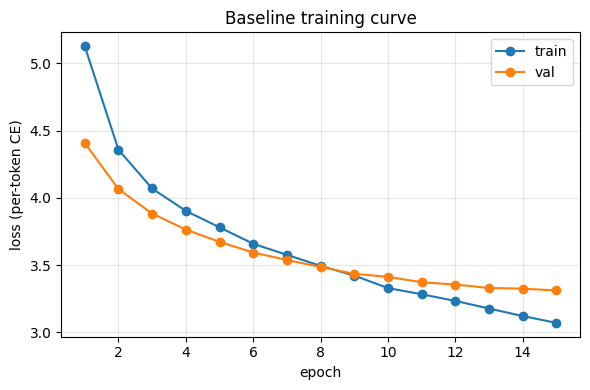

/venv/main/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


In [16]:
# @title **Loss Curves**
# Loss curves — quick sanity check that something is learning
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, EPOCHS+1), history['train'], '-o', label='train')
ax.plot(range(1, EPOCHS+1), history['val'],   '-o', label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('loss (per-token CE)')
ax.set_title('Baseline training curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# @title **Generate & Display Sample Captions**
# load the saved cache
import torch
from pathlib import Path

# load the saved cache
ocr_cache = torch.load("../data/checkpoints/ocr_cache.pt", weights_only=False)

# load the best model checkpoint (which also has vocab saved inside)
ckpt  = torch.load("../data/checkpoints/best_model.pt", weights_only=False)
vocab = ckpt["vocab"]
model = VizWizCaptioner(vocab).to(device)
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [18]:
# create split for testing
# Load cleaned records and build vocab from TRAIN split only
if not JSON_PATH.exists():
    raise FileNotFoundError(f'{JSON_PATH} not found. Run Assignment_3_EDA.ipynb first.')
with open(JSON_PATH) as f:
    records = json.load(f)

# Records from the EDA notebook may use either 'captions' or 'cleaned_captions' as the key.
# Normalize so the rest of this notebook can always assume 'cleaned_captions'.
for r in records:
    if 'cleaned_captions' not in r and 'captions' in r:
        r['cleaned_captions'] = r['captions']

by_split = {'train': [], 'val': [], 'test': []}
for r in records: by_split[r['split']].append(r)

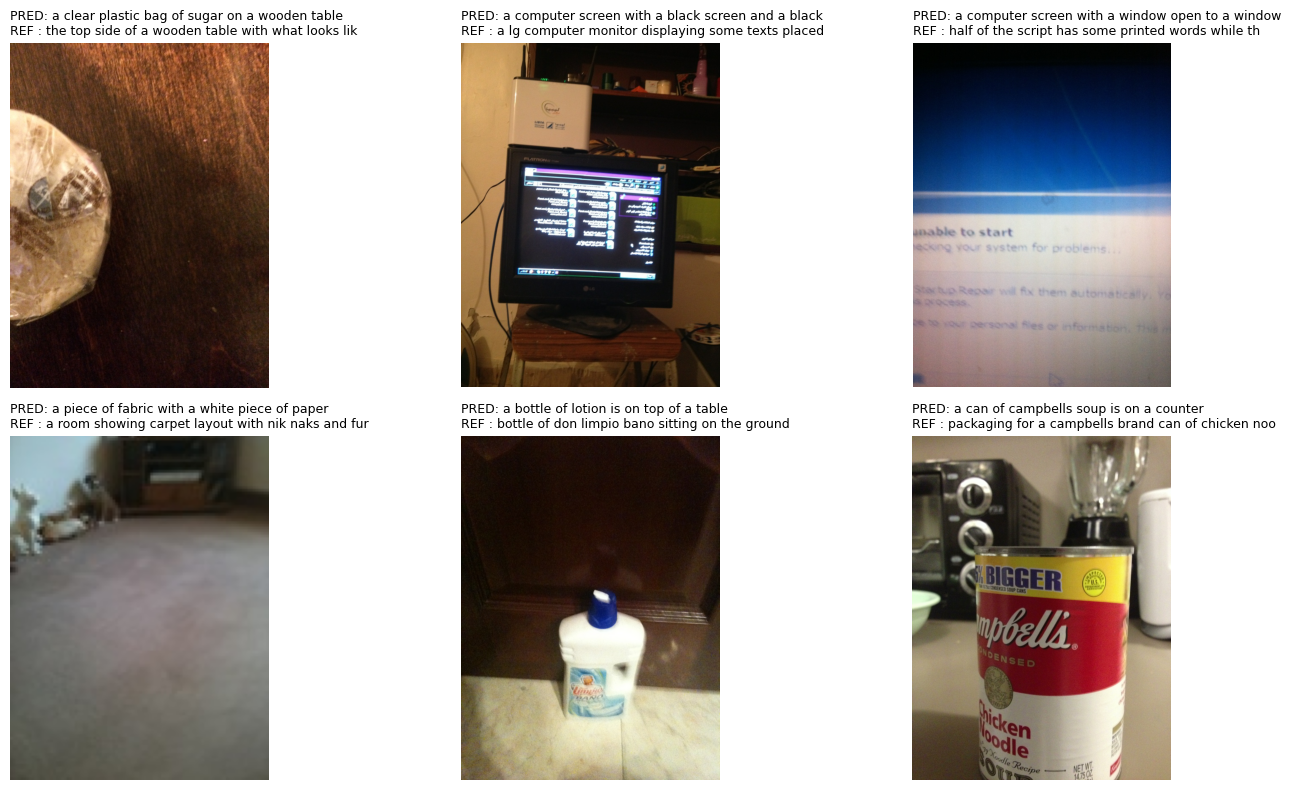

In [19]:
sample_records = random.Random(SEED).sample(by_split['test'], 6)  # local Random for reproducible figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, r in zip(axes.ravel(), sample_records):
    img_path = DATA_DIR / r['filename']
    img = Image.open(DATA_DIR / r['filename'])
    pred = generate_caption(model, img_path, vocab, ocr_cache, max_len = MAX_SEQ_LEN)
    ax.imshow(img); ax.axis('off')
    ref = r['cleaned_captions'][0][:50]
    ax.set_title(f'PRED: {pred[:50]}\nREF : {ref}', fontsize=9, loc='left')
plt.tight_layout(); plt.show()

In [29]:
# @title **Compute Corpus & Per-Image BLEU**
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import pandas as pd

def evaluate_bleu(model, records, vocab, ocr_cache, max_eval=None, split_name='test', max_len = MAX_SEQ_LEN):
    """Generate captions for each record and compute corpus BLEU + per-image BLEU."""
    sample = records[:max_eval] if max_eval else records
    hypotheses, references = [], []
    per_image_rows = []
    smoothie = SmoothingFunction().method1
    def tokenize(s): return s.split()

    for r in tqdm(sample, desc='generating'):
        img_path = DATA_DIR / r['filename']
        pred = generate_caption(model, img_path, vocab, ocr_cache, max_len)
        hyp_tokens = pred.split()
        ref_tokens = [tokenize(c) for c in r['cleaned_captions']]
        hypotheses.append(hyp_tokens)
        references.append(ref_tokens)

        # Per-image (sentence-level) BLEU
        per_image_rows.append({
            'image_id'  : r['image_id'],
            'filename'  : r['filename'],
            'hypothesis': ' '.join(hyp_tokens),
            'hyp_len'   : len(hyp_tokens),
            'ref_len'   : float(np.mean([len(rt) for rt in ref_tokens])),
            'bleu1': sentence_bleu(ref_tokens, hyp_tokens, weights=(1, 0, 0, 0),       smoothing_function=smoothie),
            'bleu2': sentence_bleu(ref_tokens, hyp_tokens, weights=(0.5, 0.5, 0, 0),   smoothing_function=smoothie),
            'bleu3': sentence_bleu(ref_tokens, hyp_tokens, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
            'bleu4': sentence_bleu(ref_tokens, hyp_tokens, weights=(0.25,)*4,          smoothing_function=smoothie),
            'reference_1': r['cleaned_captions'][0],
        })

    weights = [(1.0, 0, 0, 0), (0.5, 0.5, 0, 0), (1/3, 1/3, 1/3, 0), (0.25,)*4]
    scores = {}
    print(f'\nCorpus BLEU scores on {split_name}:')
    for n, w in enumerate(weights, 1):
        s = corpus_bleu(references, hypotheses, weights=w, smoothing_function=smoothie)
        scores[f'BLEU-{n}'] = s
        print(f'  BLEU-{n}: {s:.4f}')

    return scores, hypotheses, references, pd.DataFrame(per_image_rows)

# scores, hyps, refs, per_image_df = evaluate_bleu(model, by_split['test'], vocab, ocr_cache, split_name='test')

In [28]:
# === 1. Train BLEU (sampled) ===
TRAIN_SAMPLE_SIZE = 500
train_sample = random.Random(SEED).sample(by_split['train'], min(TRAIN_SAMPLE_SIZE, len(by_split['train'])))
print(f'--- Evaluating BLEU on TRAIN ({len(train_sample)} random sample) ---')
train_scores, _, _, _ = evaluate_bleu(model, train_sample, vocab, ocr_cache, split_name='train')

# === 2. Val BLEU (full val) ===
print(f'\n--- Evaluating BLEU on VAL ({len(by_split["val"])} images) ---')
val_scores, _, _, _ = evaluate_bleu(model, by_split['val'], vocab, ocr_cache, split_name='val')

# === 3. Test BLEU (full test) — headline + downstream visualisations ===
print(f'\n--- Evaluating BLEU on TEST ({len(by_split["test"])} images) — headline metric ---')
scores, hyps, refs, per_image_df = evaluate_bleu(model, by_split['test'], vocab, ocr_cache, split_name='test')

# === Three-way comparison ===
all_scores = {'train (sample)': train_scores, 'val': val_scores, 'test': scores}
print('\n=== Three-way BLEU comparison ===')
comparison_df = pd.DataFrame({
    name: [all_scores[name][f'BLEU-{n}'] for n in range(1, 5)]
    for name in all_scores
}, index=[f'BLEU-{n}' for n in range(1, 5)])
print(comparison_df.round(4).to_string())

--- Evaluating BLEU on TRAIN (500 random sample) ---


generating: 100%|██████████| 500/500 [01:05<00:00,  7.64it/s]



Corpus BLEU scores on train:
  BLEU-1: 0.5730
  BLEU-2: 0.3889
  BLEU-3: 0.2491
  BLEU-4: 0.1540

--- Evaluating BLEU on VAL (1098 images) ---


generating: 100%|██████████| 1098/1098 [02:05<00:00,  8.75it/s]



Corpus BLEU scores on val:
  BLEU-1: 0.5667
  BLEU-2: 0.3747
  BLEU-3: 0.2401
  BLEU-4: 0.1498

--- Evaluating BLEU on TEST (733 images) — headline metric ---


generating: 100%|██████████| 733/733 [01:22<00:00,  8.86it/s]



Corpus BLEU scores on test:
  BLEU-1: 0.5559
  BLEU-2: 0.3641
  BLEU-3: 0.2310
  BLEU-4: 0.1426

=== Three-way BLEU comparison ===
        train (sample)     val    test
BLEU-1          0.5730  0.5667  0.5559
BLEU-2          0.3889  0.3747  0.3641
BLEU-3          0.2491  0.2401  0.2310
BLEU-4          0.1540  0.1498  0.1426


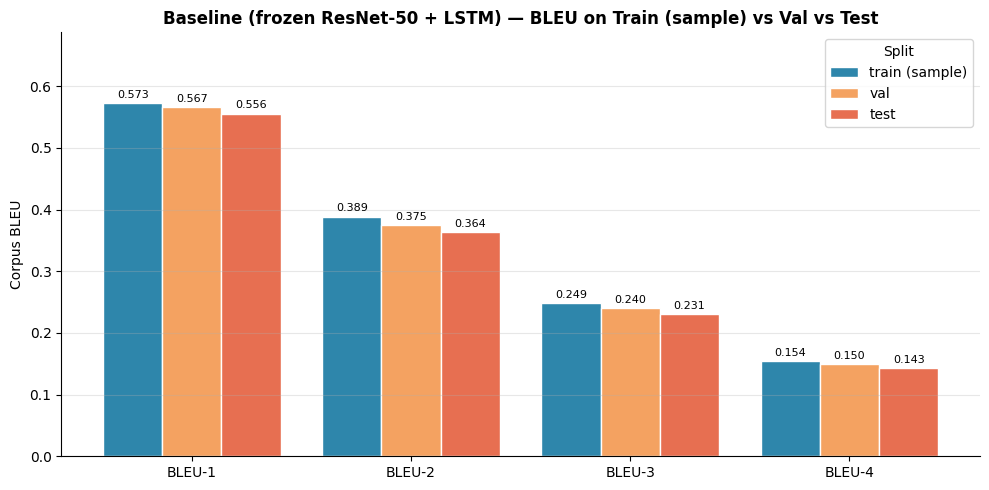


Gap analysis (positive = first split scores higher than second):
  BLEU-1   train=0.5730  val=0.5667  test=0.5559
  BLEU-2   train=0.3889  val=0.3747  test=0.3641
  BLEU-3   train=0.2491  val=0.2401  test=0.2310
  BLEU-4   train=0.1540  val=0.1498  test=0.1426

  train-val gap   BLEU-4: +0.0042
  val-test gap    BLEU-4: +0.0072

Diagnostic:
  Healthy fit: train-val BLEU-4 gap = +0.0042
  Val and test agree (gap = +0.0072) — splits are representative.


In [30]:
# @title **Grouped Bar Chart — Train vs Val vs Test BLEU**
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
splits = list(all_scores.keys())
colors = {'train (sample)': '#2E86AB', 'val': '#F4A261', 'test': '#E76F51'}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.27

for i, split in enumerate(splits):
    vals = [all_scores[split][m] for m in metrics]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=split, color=colors[split], edgecolor='white', linewidth=1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Corpus BLEU')
ax.set_title('Baseline (frozen ResNet-50 + LSTM) — BLEU on Train (sample) vs Val vs Test', fontweight='bold')
ax.legend(title='Split', loc='upper right')
ax.set_ylim(0, max(max(all_scores[s].values()) for s in splits) * 1.20)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# Gap analysis
print('\nGap analysis (positive = first split scores higher than second):')
for m in metrics:
    print(f'  {m:8s} train={train_scores[m]:.4f}  val={val_scores[m]:.4f}  test={scores[m]:.4f}')
print()
print(f'  {"train-val gap":15s} BLEU-4: {train_scores["BLEU-4"]-val_scores["BLEU-4"]:+.4f}')
print(f'  {"val-test gap":15s} BLEU-4: {val_scores["BLEU-4"]-scores["BLEU-4"]:+.4f}')

print('\nDiagnostic:')
gap_train_val = train_scores['BLEU-4'] - val_scores['BLEU-4']
gap_val_test  = val_scores['BLEU-4'] - scores['BLEU-4']
if gap_train_val > 0.05:
    print(f'  Overfitting: train-val BLEU-4 gap = {gap_train_val:+.4f}')
elif gap_train_val > 0.02:
    print(f'  Mild overfitting: train-val BLEU-4 gap = {gap_train_val:+.4f}')
else:
    print(f'  Healthy fit: train-val BLEU-4 gap = {gap_train_val:+.4f}')
if abs(gap_val_test) > 0.03:
    print(f'  Val/test diverge (gap = {gap_val_test:+.4f}) — flag in limitations.')
else:
    print(f'  Val and test agree (gap = {gap_val_test:+.4f}) — splits are representative.')

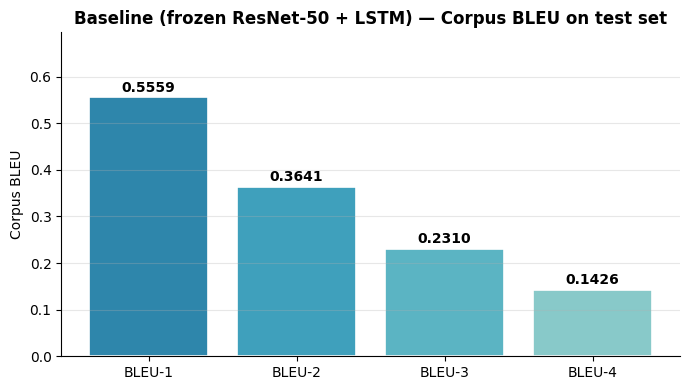

In [31]:
# @title **BLEU Bar Chart**
fig, ax = plt.subplots(figsize=(7, 4))
names  = list(scores.keys())
values = list(scores.values())
colors = ['#2E86AB', '#3FA0BC', '#5BB4C3', '#88C9C9']
bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Corpus BLEU')
ax.set_title('Baseline (frozen ResNet-50 + LSTM) — Corpus BLEU on test set', fontweight='bold')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

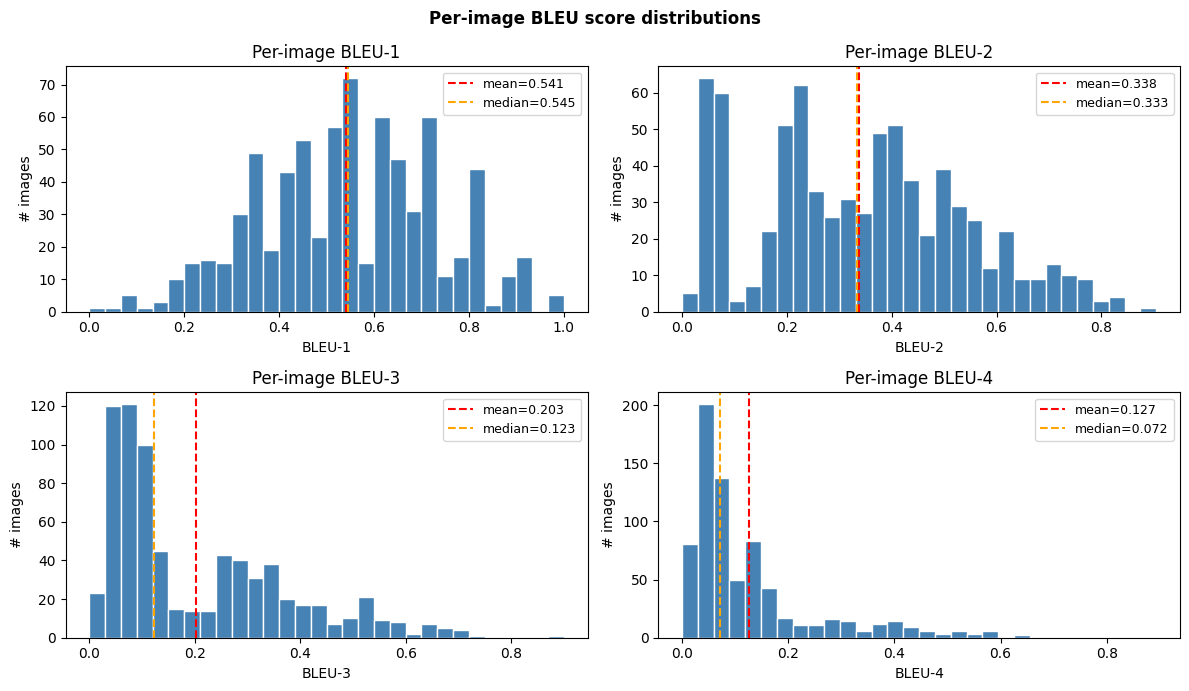


Per-image BLEU statistics:
          bleu1     bleu2     bleu3     bleu4
count  733.0000  733.0000  733.0000  733.0000
mean     0.5409    0.3377    0.2027    0.1266
std      0.1846    0.1978    0.1698    0.1283
min      0.0000    0.0000    0.0000    0.0000
25%      0.4000    0.1930    0.0741    0.0474
50%      0.5455    0.3333    0.1227    0.0718
75%      0.6667    0.4830    0.3099    0.1477
max      1.0000    0.9045    0.8993    0.8932


In [32]:
# @title **Per-Image BLEU Distribution**
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, n in zip(axes.ravel(), [1, 2, 3, 4]):
    col = f'bleu{n}'
    ax.hist(per_image_df[col], bins=30, color='steelblue', edgecolor='white')
    mean_v = per_image_df[col].mean()
    median_v = per_image_df[col].median()
    ax.axvline(mean_v,   ls='--', color='red',    label=f'mean={mean_v:.3f}')
    ax.axvline(median_v, ls='--', color='orange', label=f'median={median_v:.3f}')
    ax.set_xlabel(f'BLEU-{n}'); ax.set_ylabel('# images')
    ax.set_title(f'Per-image BLEU-{n}')
    ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Per-image BLEU score distributions', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nPer-image BLEU statistics:')
print(per_image_df[['bleu1', 'bleu2', 'bleu3', 'bleu4']].describe().round(4))

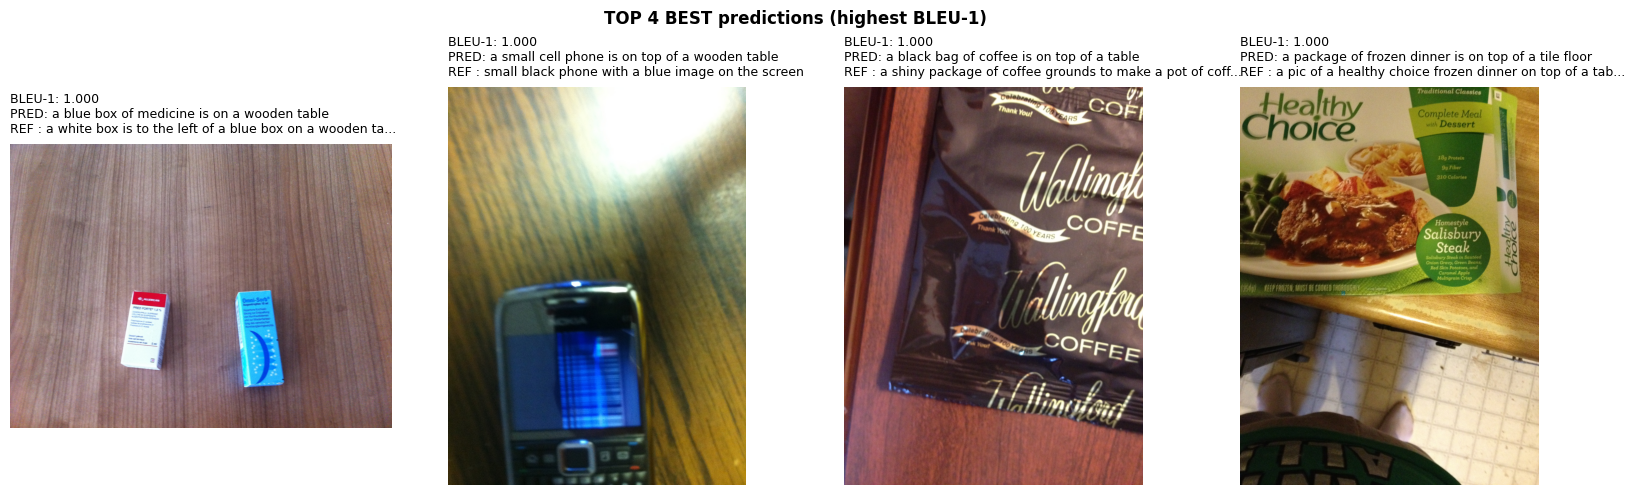

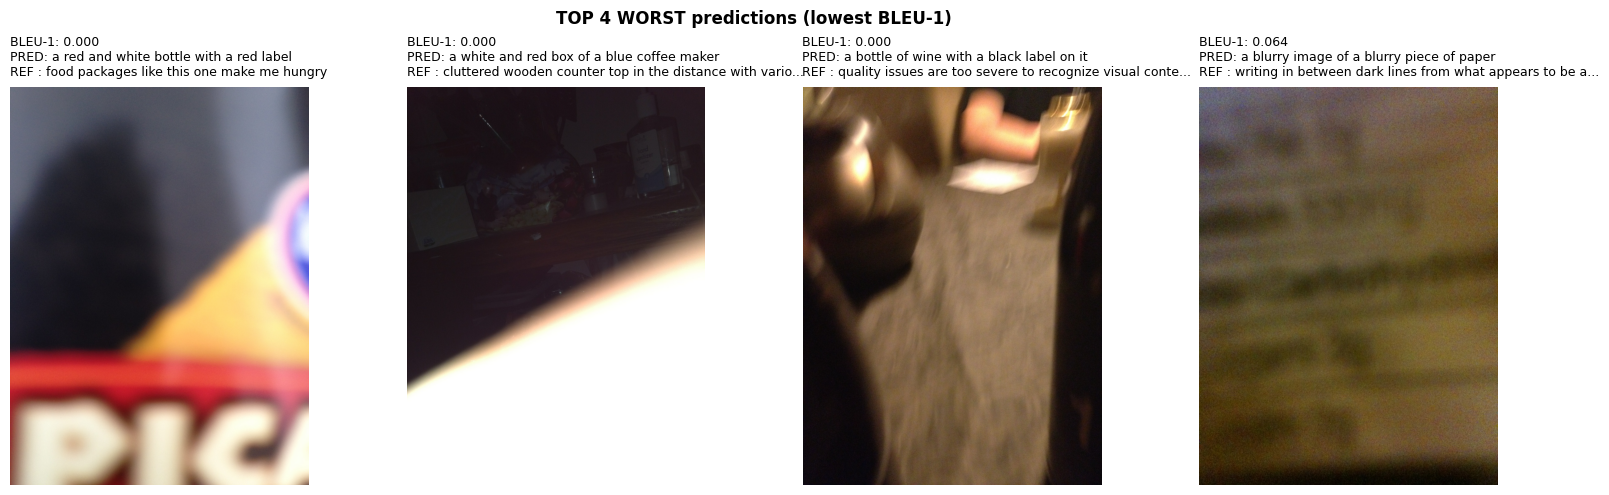

In [23]:
# @title **Best vs Worst Predictions**
TOP_N = 4
best  = per_image_df.nlargest(TOP_N,  'bleu1').reset_index(drop=True)
worst = per_image_df.nsmallest(TOP_N, 'bleu1').reset_index(drop=True)

def show_predictions(df, title):
    fig, axes = plt.subplots(1, TOP_N, figsize=(4 * TOP_N, 5))
    if TOP_N == 1: axes = [axes]
    for ax, (_, row) in zip(axes, df.iterrows()):
        img = Image.open(DATA_DIR / row['filename'])
        ax.imshow(img); ax.axis('off')
        pred = row['hypothesis'][:55] + ('...' if len(row['hypothesis']) > 55 else '')
        ref  = row['reference_1'][:55] + ('...' if len(row['reference_1']) > 55 else '')
        ax.set_title(f'BLEU-1: {row["bleu1"]:.3f}\nPRED: {pred}\nREF : {ref}',
                     fontsize=9, loc='left', pad=8)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

show_predictions(best,  f'TOP {TOP_N} BEST predictions (highest BLEU-1)')
show_predictions(worst, f'TOP {TOP_N} WORST predictions (lowest BLEU-1)')

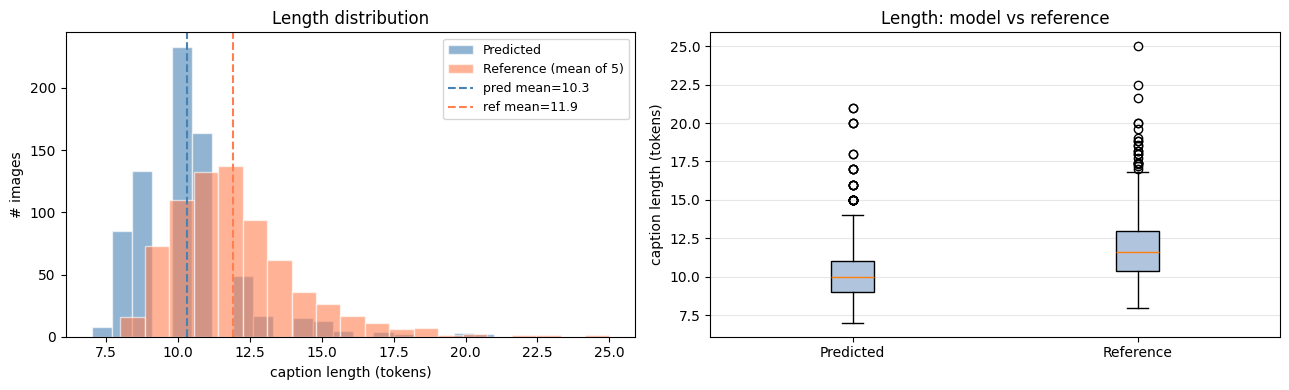

Predicted lengths : mean=10.3  median=10.0  range=[7, 21]
Reference lengths : mean=11.9  median=11.6


In [24]:
# @title **Caption Length Comparison**
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograms overlaid
axes[0].hist(per_image_df['hyp_len'], bins=20, alpha=0.6, label='Predicted',  color='steelblue', edgecolor='white')
axes[0].hist(per_image_df['ref_len'], bins=20, alpha=0.6, label='Reference (mean of 5)', color='coral', edgecolor='white')
axes[0].axvline(per_image_df['hyp_len'].mean(), ls='--', color='steelblue', label=f'pred mean={per_image_df["hyp_len"].mean():.1f}')
axes[0].axvline(per_image_df['ref_len'].mean(), ls='--', color='coral',     label=f'ref mean={per_image_df["ref_len"].mean():.1f}')
axes[0].set_xlabel('caption length (tokens)'); axes[0].set_ylabel('# images')
axes[0].set_title('Length distribution'); axes[0].legend(fontsize=9)

# Box plot side-by-side
axes[1].boxplot([per_image_df['hyp_len'], per_image_df['ref_len']],
                tick_labels=['Predicted', 'Reference'],
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_ylabel('caption length (tokens)')
axes[1].set_title('Length: model vs reference')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Predicted lengths : mean={per_image_df["hyp_len"].mean():.1f}  median={per_image_df["hyp_len"].median():.1f}  range=[{per_image_df["hyp_len"].min()}, {per_image_df["hyp_len"].max()}]')
print(f'Reference lengths : mean={per_image_df["ref_len"].mean():.1f}  median={per_image_df["ref_len"].median():.1f}')

Unique words used by MODEL      : 284
Unique words in REFERENCES      : 3,486
Diversity ratio (model / ref)   : 8.15%
Total predicted tokens          : 7,567
Total reference tokens          : 38,476


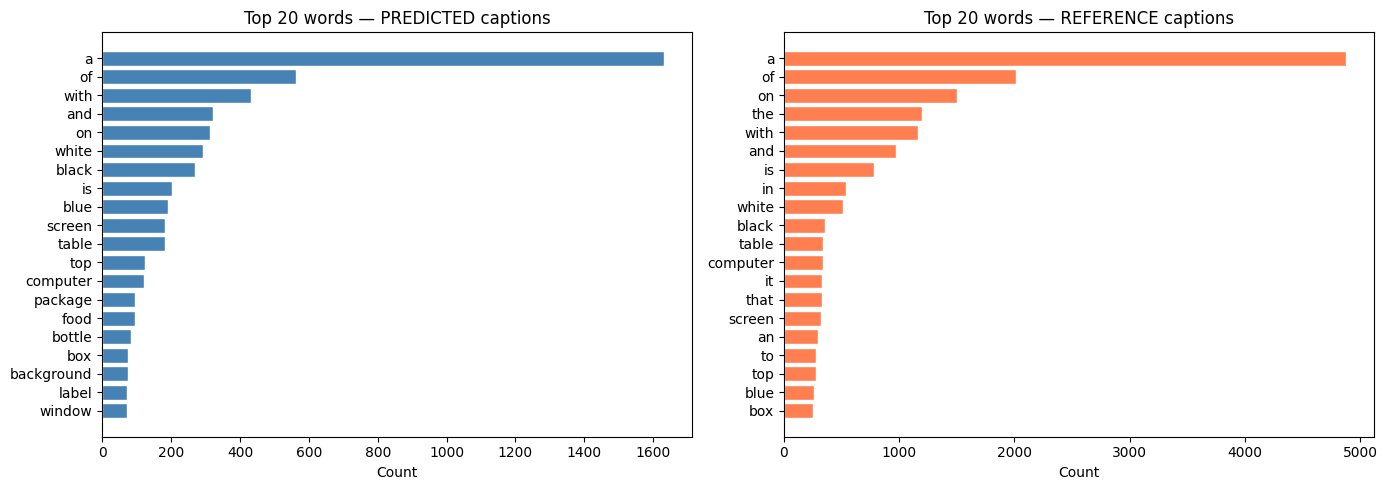

In [25]:
# @title **Vocabulary Usage**
from collections import Counter

hyp_words = Counter(t for h in hyps for t in h)
ref_words = Counter(t for refs_ in refs for r in refs_ for t in r)

print(f'Unique words used by MODEL      : {len(hyp_words):,}')
print(f'Unique words in REFERENCES      : {len(ref_words):,}')
print(f'Diversity ratio (model / ref)   : {len(hyp_words)/max(len(ref_words),1):.2%}')
print(f'Total predicted tokens          : {sum(hyp_words.values()):,}')
print(f'Total reference tokens          : {sum(ref_words.values()):,}')

TOP_N = 20
top_pred = hyp_words.most_common(TOP_N)
top_ref  = ref_words.most_common(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, counts = zip(*top_pred)
axes[0].barh(list(reversed(words)), list(reversed(counts)), color='steelblue', edgecolor='white')
axes[0].set_xlabel('Count'); axes[0].set_title(f'Top {TOP_N} words — PREDICTED captions')

words, counts = zip(*top_ref)
axes[1].barh(list(reversed(words)), list(reversed(counts)), color='coral', edgecolor='white')
axes[1].set_xlabel('Count'); axes[1].set_title(f'Top {TOP_N} words — REFERENCE captions')

plt.tight_layout(); plt.show()

In [26]:
# @title **Summary Table**
summary = pd.DataFrame([
    ('Corpus BLEU-1',             f'{scores["BLEU-1"]:.4f}'),
    ('Corpus BLEU-2',             f'{scores["BLEU-2"]:.4f}'),
    ('Corpus BLEU-3',             f'{scores["BLEU-3"]:.4f}'),
    ('Corpus BLEU-4',             f'{scores["BLEU-4"]:.4f}'),
    ('Mean per-image BLEU-1',     f'{per_image_df["bleu1"].mean():.4f}'),
    ('Mean per-image BLEU-4',     f'{per_image_df["bleu4"].mean():.4f}'),
    ('Median per-image BLEU-1',   f'{per_image_df["bleu1"].median():.4f}'),
    ('Mean predicted length',     f'{per_image_df["hyp_len"].mean():.1f} tokens'),
    ('Mean reference length',     f'{per_image_df["ref_len"].mean():.1f} tokens'),
    ('Unique words (predicted)',  f'{len(hyp_words):,}'),
    ('Unique words (reference)',  f'{len(ref_words):,}'),
    ('Vocabulary diversity',      f'{len(hyp_words)/max(len(ref_words),1):.2%}'),
    ('# val images evaluated',    f'{len(per_image_df):,}'),
    ('# training epochs',         f'{EPOCHS}'),
    # ('Trainable parameters',      f'{n_trainable:,}'),
    ('Device',                    str(device)),
], columns=['Metric', 'Value'])

print(summary.to_string(index=False))

                  Metric       Value
           Corpus BLEU-1      0.5626
           Corpus BLEU-2      0.3614
           Corpus BLEU-3      0.2256
           Corpus BLEU-4      0.1368
   Mean per-image BLEU-1      0.5451
   Mean per-image BLEU-4      0.1225
 Median per-image BLEU-1      0.5455
   Mean predicted length 10.3 tokens
   Mean reference length 11.9 tokens
Unique words (predicted)         284
Unique words (reference)       3,486
    Vocabulary diversity       8.15%
  # val images evaluated         733
       # training epochs          15
                  Device        cuda
